In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class LinearRegression:
    def __init__(self):
        self.intercept_: float = 0.0
        self.slope_: float = 0.0

    def predict(self, Xi):
        return self.intercept_ + (self.slope_ * Xi)

In [3]:
def mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true_arr = np.asarray(y_true).flatten()
    y_pred_arr = np.asarray(y_pred).flatten()
    return float (np.mean((y_true_arr - y_pred_arr)**2))

In [4]:
def optimizer (X: np.ndarray,
               y: np.ndarray,
               init_intercept: float = 0.0,
               init_slope: float = 0.0,
               learning_rate: float = 0.005,
               epochs: int = 5000) -> tuple[float, float]:
    """
    Performs stable gradient descent using a balanced learning rate (learning_rate = 0.005).
    """
    X_flat = X.flatten()
    y_flat = y.flatten()
    n = len(X_flat)
    
    # Internal centering for perfect numerical stability
    X_mean = np.mean(X_flat)
    X_centered = X_flat - X_mean
    
    slope_centered = init_slope
    intercept_centered = init_intercept + (init_slope * X_mean)
    
    for epoch in range(epochs):
        y_pred = intercept_centered + (slope_centered * X_centered)
        error = y_flat - y_pred
        
        # Gradients
        d_slope = (-2 / n) * np.sum(X_centered * error)
        d_intercept = (-2 / n) * np.sum(error)
        
        # Parameter Updates
        slope_centered -= learning_rate * d_slope
        intercept_centered -= learning_rate * d_intercept
        
    final_slope = slope_centered
    final_intercept = intercept_centered - (slope_centered * X_mean)
        
    return final_intercept, final_slope

In [5]:
X_data = np.array([160, 171, 182, 180, 154])
y_data = np.array([72, 76, 77, 83, 76])

In [15]:
model = LinearRegression()
model.intercept_ = 30.0 
model.slope_ = 0.25

In [16]:
initial_loss = mean_squared_error(y_data, model.predict(X_data))

In [17]:
X_line = np.linspace(150, 190, 100)
y_pred_before = model.predict(X_line)

In [18]:
gd_intercept, gd_slope = optimizer (
    X_data, y_data, 
    init_intercept=model.intercept_, 
    init_slope=model.slope_,
    learning_rate=0.005, # Fixed from 0.01 to avoid overshooting
    epochs=5000
)

In [19]:
model.intercept_ = gd_intercept
model.slope_ = gd_slope
final_loss = mean_squared_error(y_data, model.predict(X_data))
y_pred_after = model.predict(X_line)

In [20]:
print(f"Before GD Loss: {initial_loss:.4f} (Intercept: 30.0, Slope: 0.25)")
print(f"After GD Loss:  {final_loss:.4f} (Intercept: {gd_intercept:.4f}, Slope: {gd_slope:.4f})")

Before GD Loss: 27.4125 (Intercept: 30.0, Slope: 0.25)
After GD Loss:  7.3947 (Intercept: 41.6308, Slope: 0.2076)


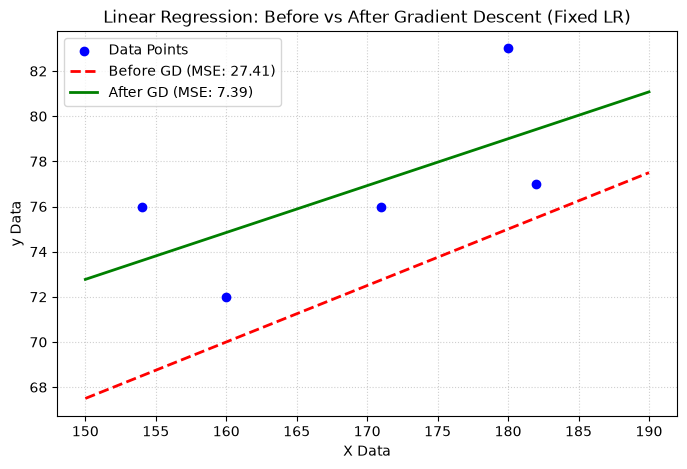

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, color='blue', zorder=5, label='Data Points')
plt.plot(X_line, y_pred_before, color='red', linestyle='--', linewidth=2, label=f'Before GD (MSE: {initial_loss:.2f})')
plt.plot(X_line, y_pred_after, color='green', linestyle='-', linewidth=2, label=f'After GD (MSE: {final_loss:.2f})')
plt.title('Linear Regression: Before vs After Gradient Descent (Fixed LR)')
plt.xlabel('X Data')
plt.ylabel('y Data')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()